
## Introduction to Data Visualization

Welcome to the Data Visualization notebook for the Employee Performance Analysis project at INX Future Inc. This notebook plays a crucial role in our analytical efforts, transforming complex datasets into clear, insightful visual representations that facilitate deeper understanding and communication of the findings.

### Objectives:
- **Visualize Distribution and Relationships**: Employ various visualization tools to display the distribution of key features and explore the relationships between different variables related to employee performance.
- **Highlight Key Insights**: Use visual aids to highlight significant patterns, trends, and anomalies that might not be apparent from raw data alone.
- **Support Data-Driven Decisions**: Provide visual evidence that supports decision-making processes, helping stakeholders to grasp complicated concepts and data-driven insights quickly and effectively.

Throughout this notebook, we will utilize libraries such as Matplotlib, Seaborn, and possibly interactive visualization tools like Plotly, to create a range of static and interactive plots. These visualizations will cover everything from simple histograms and bar charts to complex scatter plots and heat maps, each chosen to best represent the underlying data and support the analytical narrative.

Let's begin our visual exploration to uncover actionable insights and drive the project towards strategic outcomes.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
file_path = r'C:\Users\moses_y\OneDrive\Desktop\ML Projects\Employee_Performance_Analysis\data\raw\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xlsx'

xls = pd.ExcelFile(file_path)

# Load each sheet into a DataFrame
df1 = pd.read_excel(xls, sheet_name=0)
df2 = pd.read_excel(xls, sheet_name=1)


# Distribution of Numerical Features

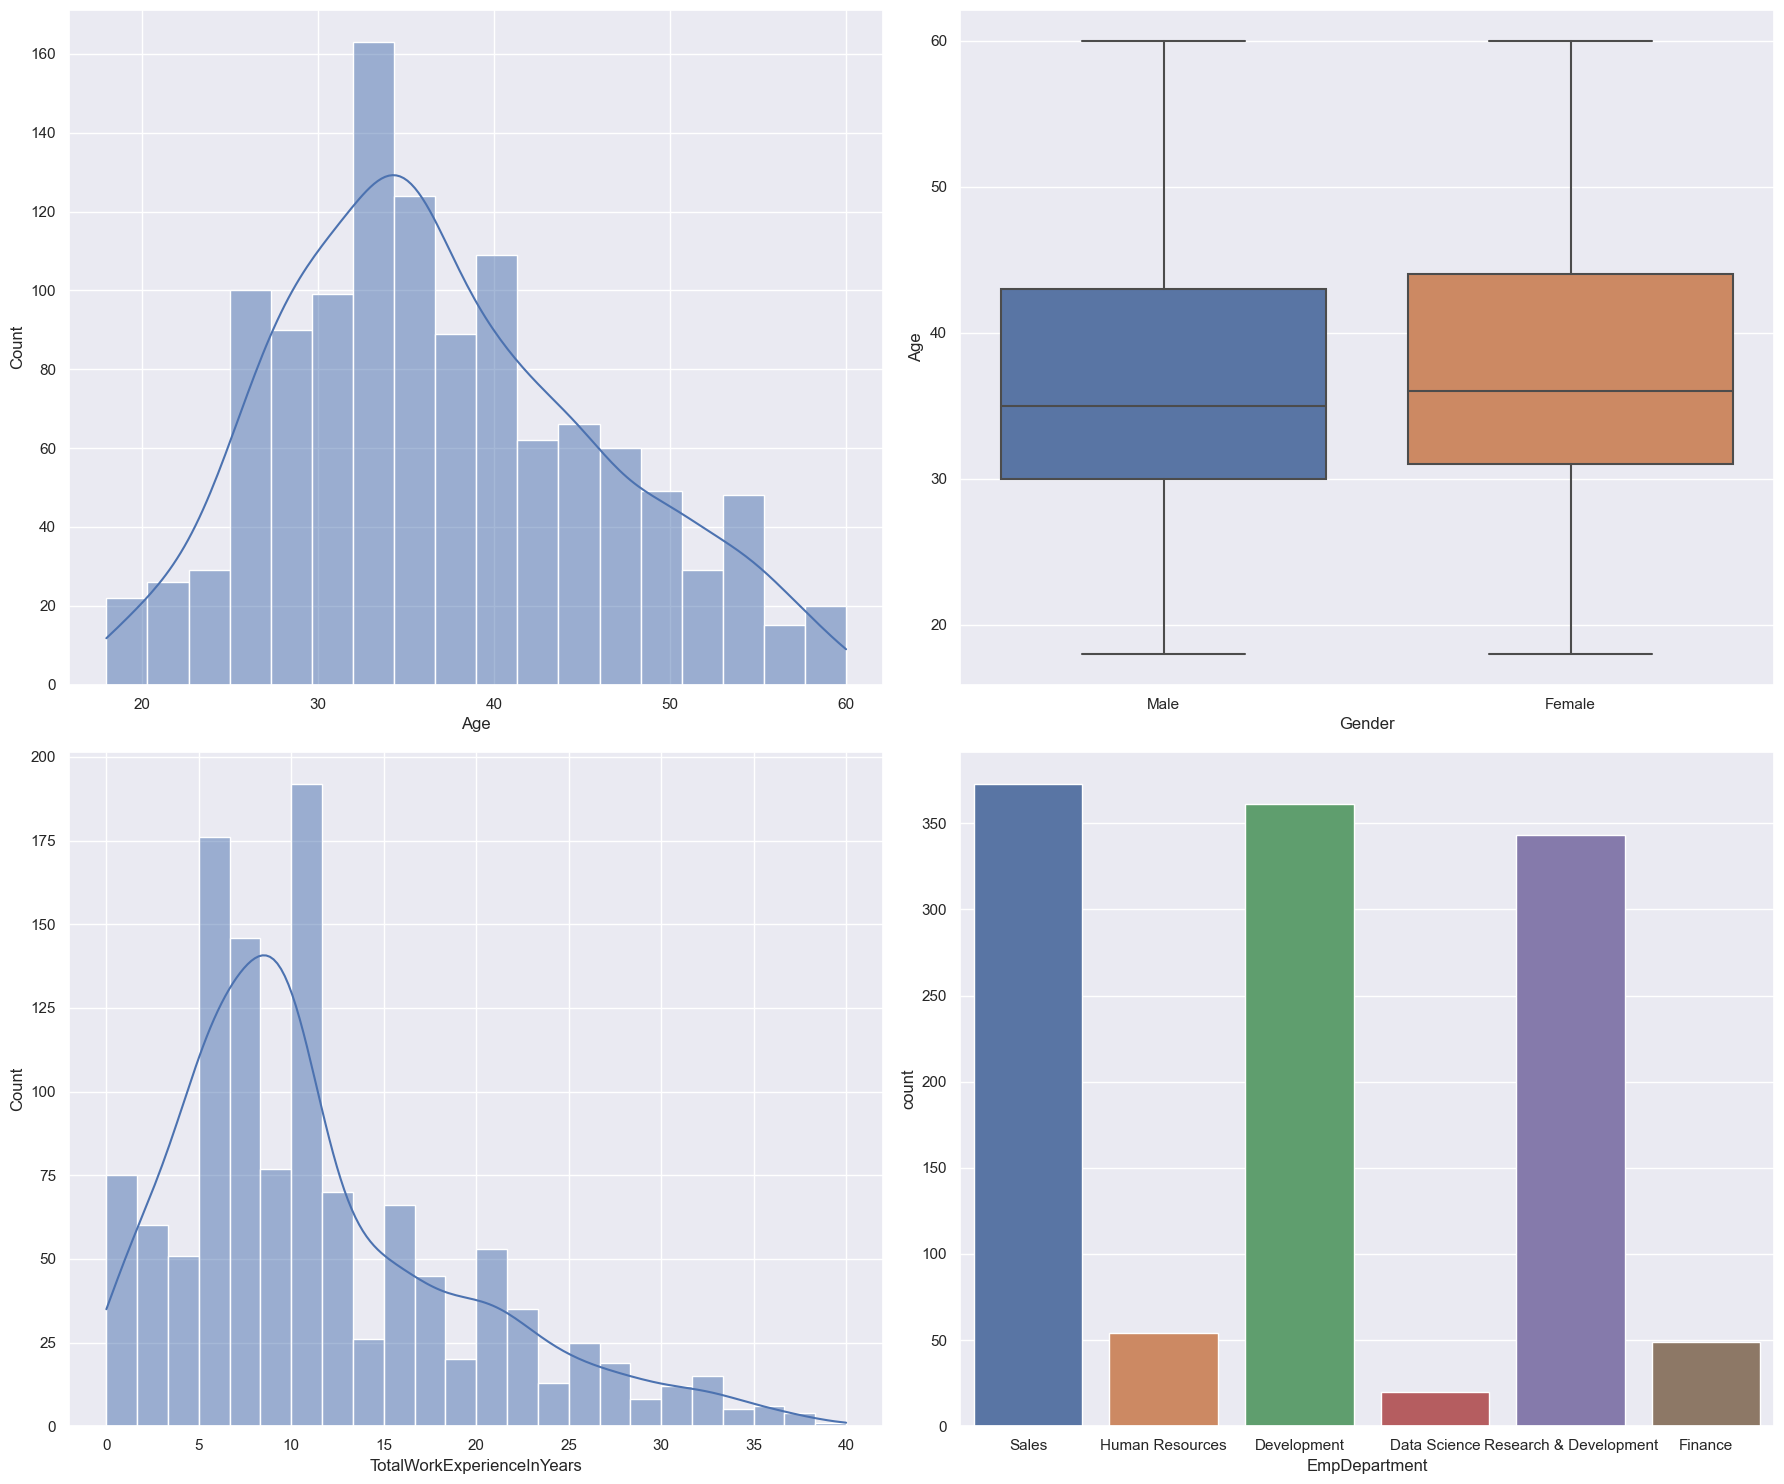

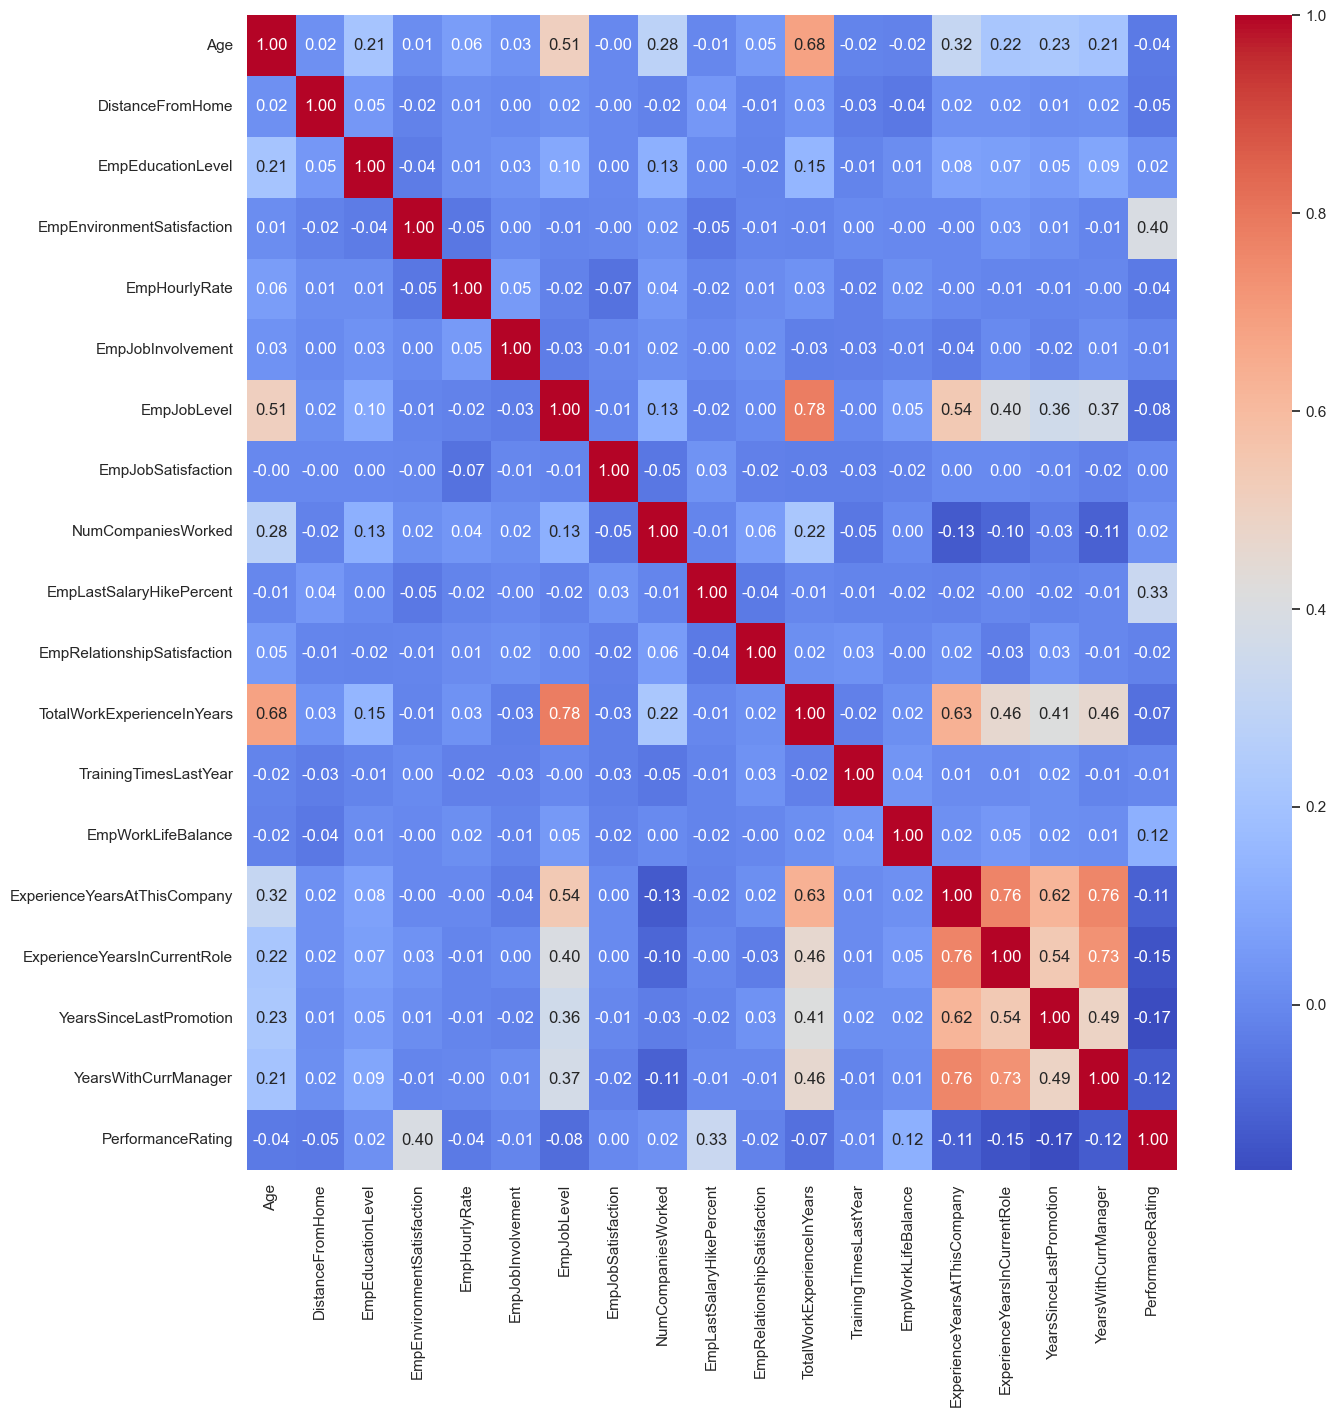

In [3]:
# Definition of numerical_cols
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns
# Correlation matrix for numerical features
corr_matrix = df1[numerical_cols].corr()

# Set visual style
sns.set(style="darkgrid")
# Plotting the distribution of key numerical features
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 15))
sns.histplot(data=df1, x='Age', kde=True, ax=axs[0, 0])
sns.boxplot(data=df1, x='Gender', y='Age', ax=axs[0, 1])
sns.histplot(data=df1, x='TotalWorkExperienceInYears', kde=True, ax=axs[1, 0])
sns.countplot(data=df1, x='EmpDepartment', ax=axs[1, 1])

plt.tight_layout()

# Show correlation heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


### Correlation Heatmap:
- The heatmap indicates varying degrees of correlation among numerical features, suggesting that certain pairs of variables might have stronger relationships that could be interesting to investigate further, especially as they pertain to employee performance.

### Visualizations:
- **Age Distribution:** Shows a fairly normal distribution with a slight right skew.
- **Total Work Experience:** Similar to age, the total work experience among employees shows a broad range, also with a right skew, indicating that the majority have moderate levels of experience while fewer have very high levels.
- **Department Count:** Highlights the predominance of Sales, Development, and R&D departments in terms of employee counts.
- **Age by Gender:** Provides insights into the age distribution across genders.


## Employee Satisfaction Levels by Department Visualization


<Figure size 1400x700 with 0 Axes>

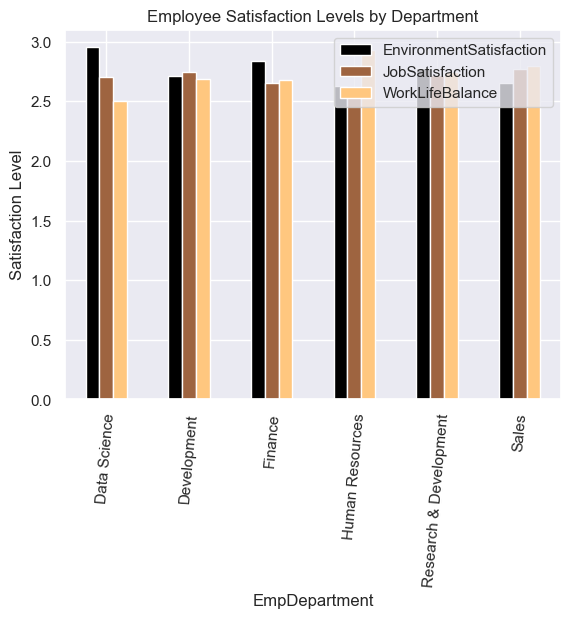

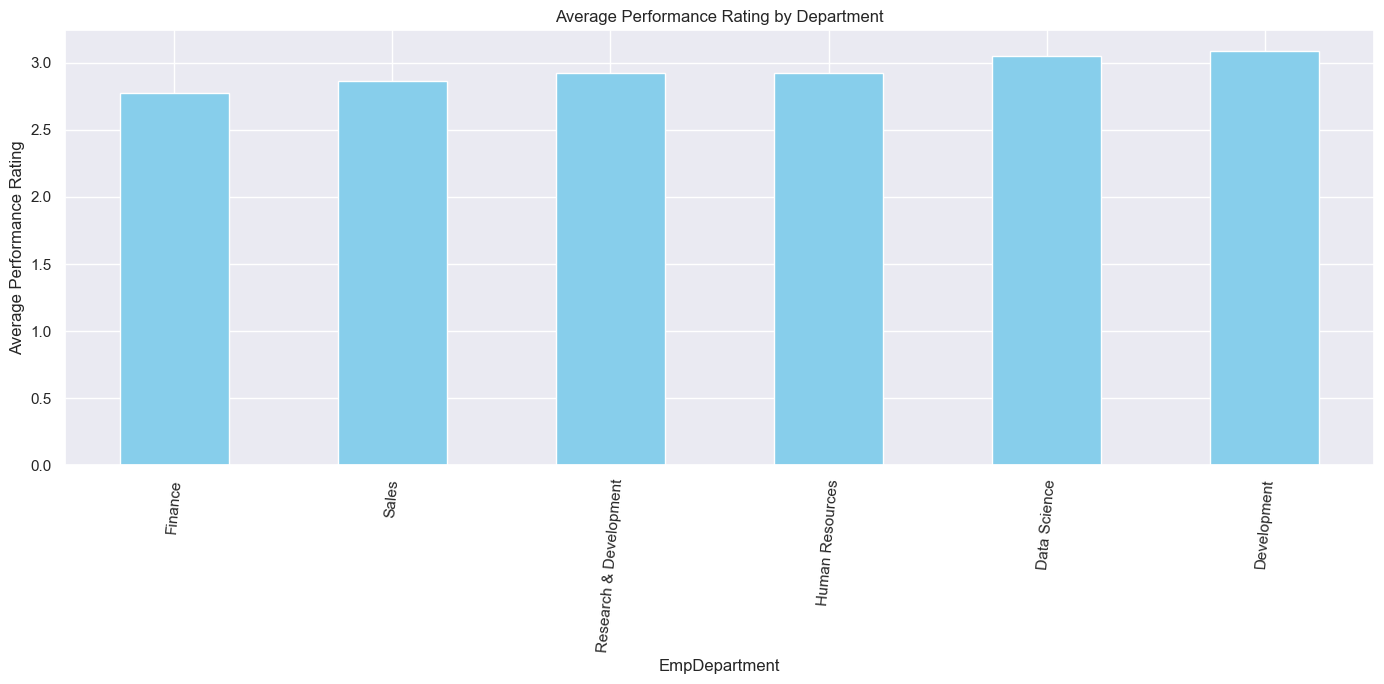

In [21]:
# Detailed Department Analysis

raw_data = df1
# Analyzing the mean performance rating by department
department_performance = raw_data.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()

# Employee satisfaction levels by department
environment_satisfaction = raw_data.groupby('EmpDepartment')['EmpEnvironmentSatisfaction'].mean()
job_satisfaction = raw_data.groupby('EmpDepartment')['EmpJobSatisfaction'].mean()
work_life_balance = raw_data.groupby('EmpDepartment')['EmpWorkLifeBalance'].mean()

# Combining the satisfaction levels for a comprehensive view
satisfaction_levels = pd.DataFrame({
    'EnvironmentSatisfaction': environment_satisfaction, 
    'JobSatisfaction': job_satisfaction, 
    'WorkLifeBalance': work_life_balance
})


# Plotting the performance and satisfaction levels by department
plt.figure(figsize=(14, 7))
satisfaction_levels.plot(kind='bar', colormap='copper')
plt.title('Employee Satisfaction Levels by Department')
plt.ylabel('Satisfaction Level')
plt.xticks(rotation=85)
plt.legend(loc='upper right')

plt.show()

plt.figure(figsize=(14, 7))
department_performance.plot(kind='bar', color='skyblue')
plt.title('Average Performance Rating by Department')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=85)
plt.tight_layout()




## Employee Satisfaction Levels by Department:
- Environment Satisfaction, Job Satisfaction, and Work-Life Balance vary across departments:
- Data Science scores high in environment satisfaction but has lower job satisfaction compared to other departments.
- Development shows relatively balanced satisfaction levels across the three categories.
- Human Resources has the highest work-life balance satisfaction, despite its middle-range performance rating.
- Sales, despite its lower performance rating average, has relatively high job satisfaction.

# Performance Rating Visualization

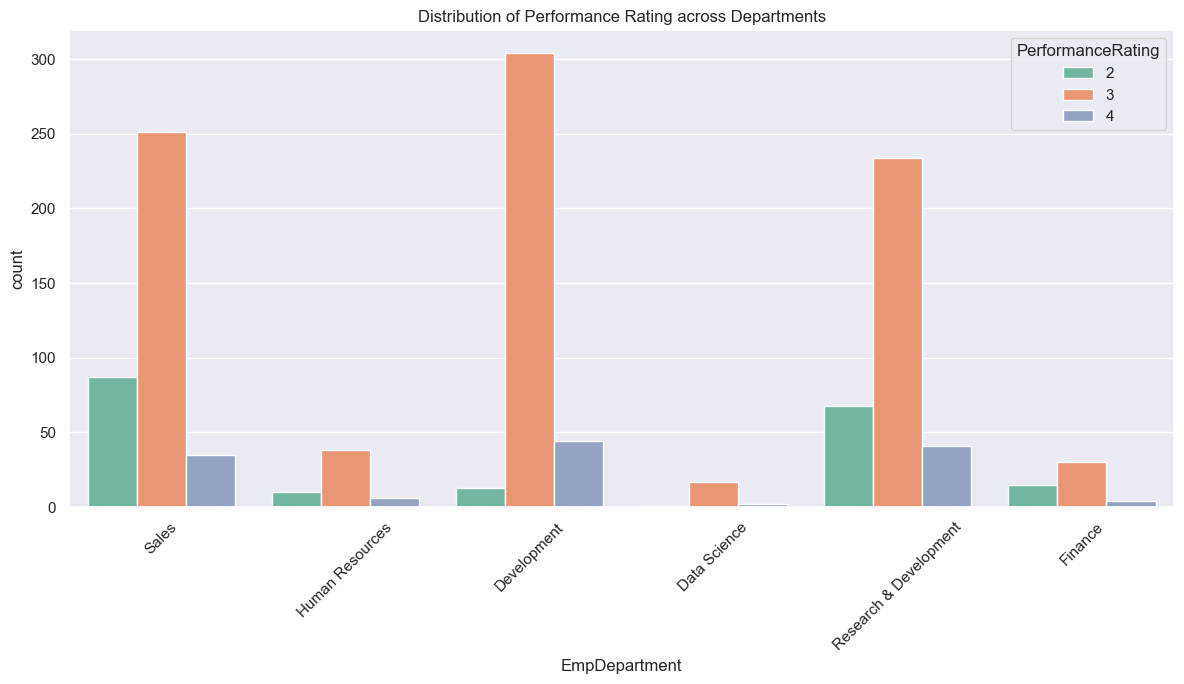

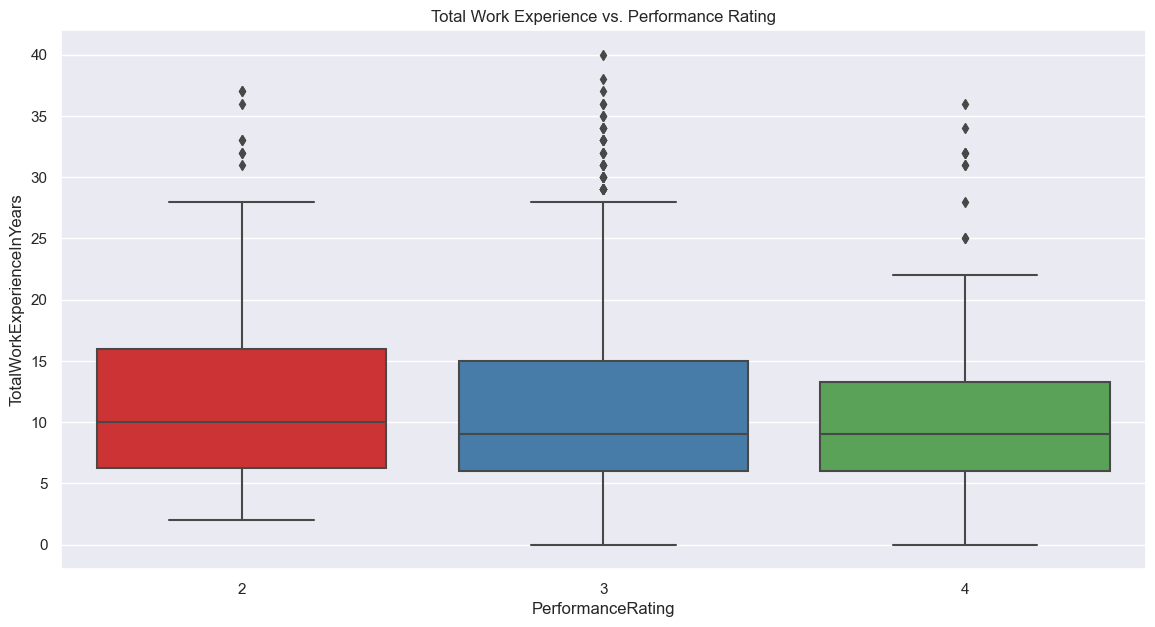

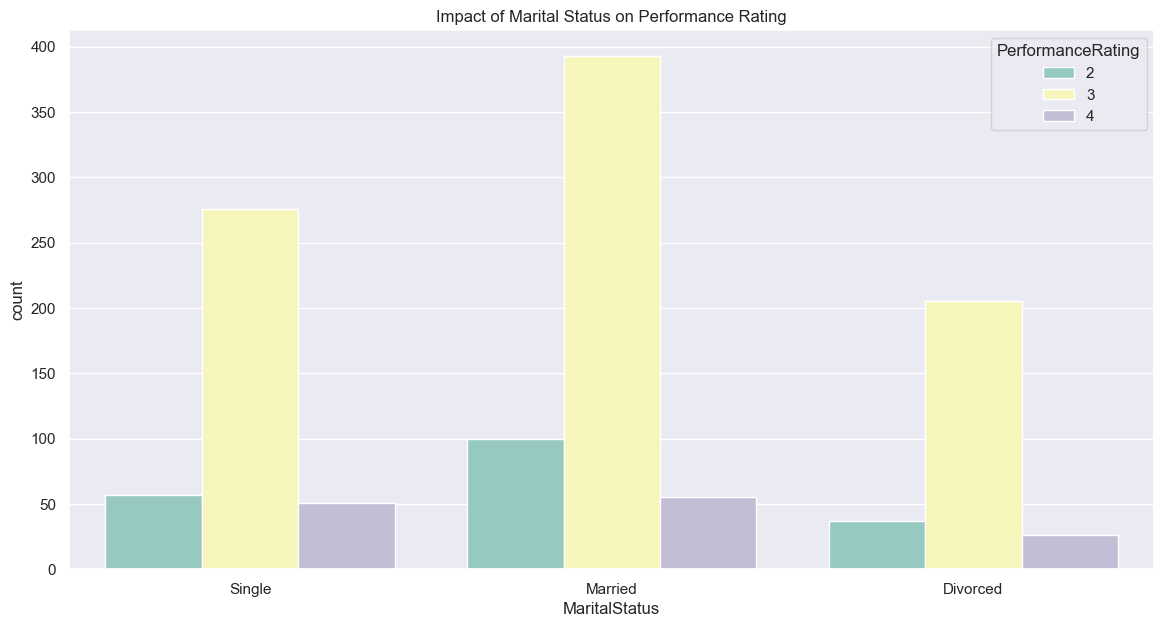

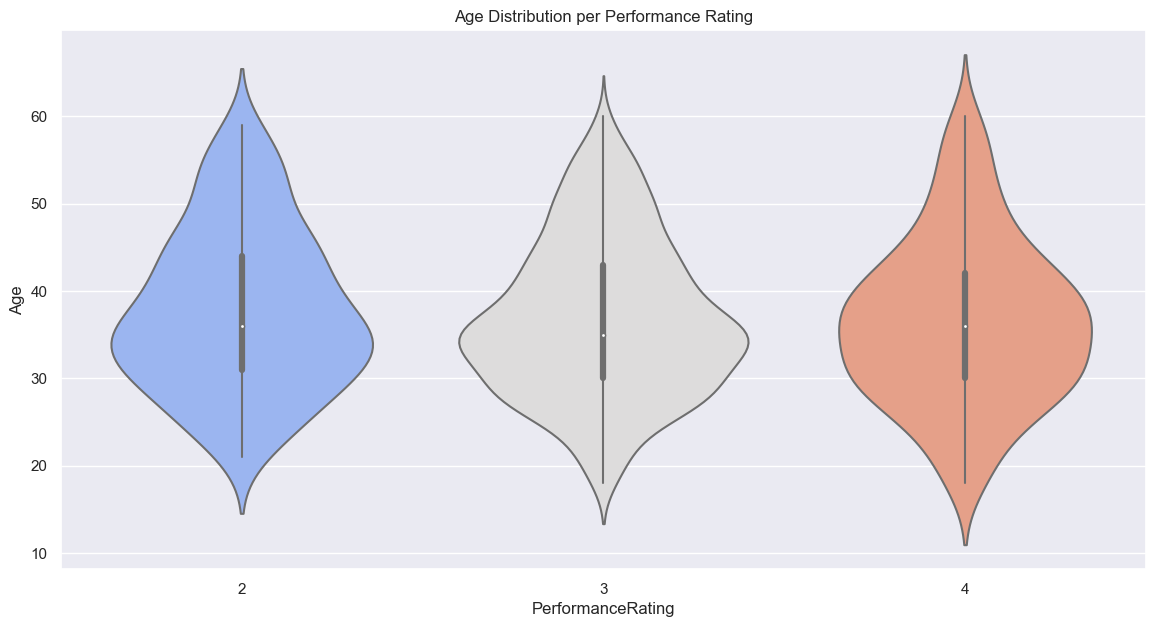

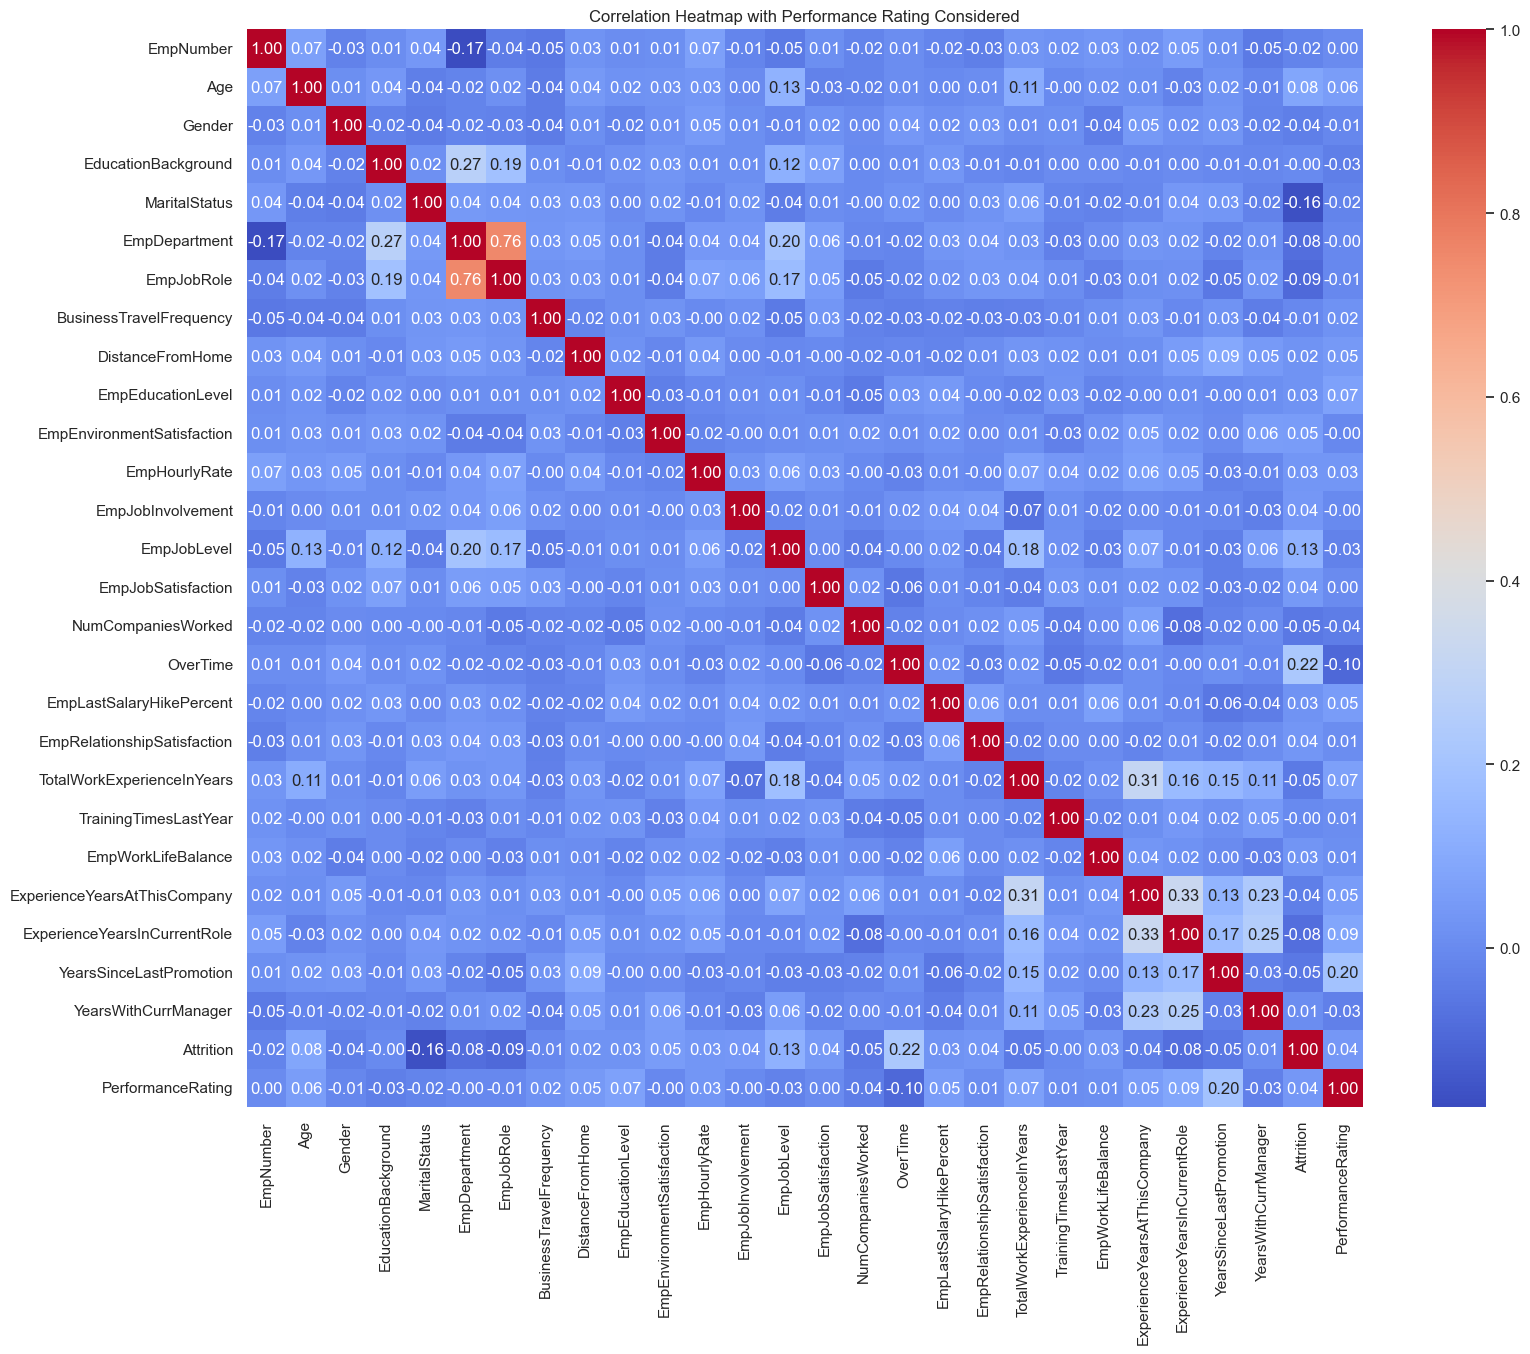

In [25]:
# Further exploring the data with a variety of visualizations to gain deeper insights

# Distribution of Employee Department and Performance Rating
plt.figure(figsize=(12, 7))
sns.countplot(data=raw_data, x='EmpDepartment', hue='PerformanceRating', palette='Set2')
plt.title('Distribution of Performance Rating across Departments')
plt.xticks(rotation=45)
plt.tight_layout()

# Relationship between Total Work Experience and Performance Rating
plt.figure(figsize=(14, 7))
sns.boxplot(data=raw_data, x='PerformanceRating', y='TotalWorkExperienceInYears', palette='Set1')
plt.title('Total Work Experience vs. Performance Rating')

# Impact of Marital Status on Performance Rating
plt.figure(figsize=(14, 7))
sns.countplot(data=raw_data, x='MaritalStatus', hue='PerformanceRating', palette='Set3')
plt.title('Impact of Marital Status on Performance Rating')

# Distribution of Age with respect to Performance Rating
plt.figure(figsize=(14, 7))
sns.violinplot(data=raw_data, x='PerformanceRating', y='Age', palette='coolwarm')
plt.title('Age Distribution per Performance Rating')

# Correlation Heatmap considering PerformanceRating as a numerical feature for more insights
performance_corr = raw_data.apply(lambda x: pd.factorize(x)[0]).corr()
plt.figure(figsize=(18, 14))
sns.heatmap(performance_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap with Performance Rating Considered')

plt.show()


The additional visualizations provide deeper insights into the dataset and help identify patterns related to employee performance at INX Future Inc.:

### Distribution of Performance Rating Across Departments:
- The distribution across departments with respect to performance ratings shows that certain departments, like Sales, Development, and Research & Development, have a wider spread of performance ratings. This could indicate a more diverse range of job roles or performance evaluation criteria within these departments.

### Total Work Experience vs. Performance Rating:
- The boxplot of total work experience by performance rating suggests that employees across different performance ratings have a broad range of work experience, indicating that experience alone may not be a direct predictor of performance rating.

### Impact of Marital Status on Performance Rating:
- The countplot showing the impact of marital status on performance rating reveals that marital status distributions are somewhat consistent across different performance ratings. This suggests that marital status might not be a significant factor in determining employee performance at INX Future Inc.

### Age Distribution per Performance Rating:
- The violin plot for age distribution across performance ratings illustrates a wide age range across all performance levels. This indicates that age is not a discriminating factor for performance ratings, highlighting that INX Future Inc. evaluates performance independent of the employees' age.

### Correlation Heatmap with Performance Rating Considered:
- By considering PerformanceRating as a numerical feature for correlation analysis, the heatmap shows relationships between performance rating and other features. While the correlations are not very strong, this visualization helps identify potential factors that might have subtle influences on performance ratings.

### Key Takeaways for Further Analysis and Modeling:
- **Department Specific Trends:** The varied distribution of performance ratings across departments may warrant a closer examination of department-specific factors or practices influencing employee performance.
- **Role of Experience and Age:** The analysis suggests that neither total work experience nor age strongly differentiates performance ratings directly, pointing towards the importance of other factors such as job role, department practices, or individual skills.
- **Marital Status and Performance:** The lack of a clear pattern between marital status and performance ratings implies that personal demographic factors might play a less significant role than professional attributes or work environment factors in determining performance.
- **Comprehensive Modeling:** For predictive modeling, considering a wide range of features including but not limited to departmental data, job roles, and other employee attributes might provide more accurate predictions of performance ratings.

These visualizations enrich the EDA phase of our data science project, where we can proceed with  feature engineering and the development of predictive models focused on employee performance analysis.